In [ ]:
import numpy as np
from collections import defaultdict
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS, OWL
import random
import matplotlib.pyplot as plt

In [61]:
INPUT_FILE = "hi_ontology_linked_infered.owl"
HI = Namespace("http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/")

### KG Augmentation

Due to the limited number of specific instances, synthetic data generation is adopted to create sufficient amount of instances for query. Noticably, the approach of the query is to presenting how HI knowledge graph can be used to answer competency questions. Thus, the result should be regarded as examples rather than scientific finding.

In [56]:
TARGET_SCENARIOS = 100
RANDOM_SEED = 123
random.seed(RANDOM_SEED)

In [57]:
def ln(uri):
    s = str(uri)
    if "#" in s:
        return s.split("#")[-1]
    return s.rstrip("/").split("/")[-1]

In [58]:
def add_type(g, subj, cls):
    g.add((subj, RDF.type, OWL.NamedIndividual))
    g.add((subj, RDF.type, cls))

In [59]:
def print_results(title, rows, headers, max_rows=None):

    print(title)
  
    print(" | ".join(headers))


    shown = rows if max_rows is None else rows[:max_rows]
    for row in shown:
        print(" | ".join("" if x is None else str(x) for x in row))

    if not rows:
        print("(no results)")
    elif max_rows is not None and len(rows) > max_rows:
        print(f"... showing {max_rows} of {len(rows)} rows")
    print()

In [60]:
# Load graph
g = Graph()
g.parse(INPUT_FILE)
g.bind("hi", HI)
g.bind("rdf", RDF)
g.bind("rdfs", RDFS)
g.bind("owl", OWL)

In [62]:
existing_scenarios = set(g.subjects(RDF.type, HI.Scenario))
current_n = len(existing_scenarios)
to_add = max(0, TARGET_SCENARIOS - current_n)

# value pooling
trust_values = list(g.subjects(RDF.type, HI.HighTrust)) \
             + list(g.subjects(RDF.type, HI.MediumTrust)) \
             + list(g.subjects(RDF.type, HI.LowTrust))

control_values = list(g.subjects(RDF.type, HI.HumanInTheLoop)) \
               + list(g.subjects(RDF.type, HI.HumanOnTheLoop)) \
               + list(g.subjects(RDF.type, HI.HumanOutOfTheLoop))

coord_values = list(g.subjects(RDF.type, HI.SequentialCoordination)) \
             + list(g.subjects(RDF.type, HI.CollaborativeCoordination)) \
             + list(g.subjects(RDF.type, HI.ParallelCoordination)) \
             + list(g.subjects(RDF.type, HI.SupervisoryCoordination))

decision_values = list(g.subjects(RDF.type, HI.HumanFinalDecisionMaker)) \
                + list(g.subjects(RDF.type, HI.AIFinalDecisionMaker)) \
                + list(g.subjects(RDF.type, HI.SharedDecisionMaking))

autonomy_values = list(g.subjects(RDF.type, HI.LowAutonomy)) \
                + list(g.subjects(RDF.type, HI.SemiAutonomous)) \
                + list(g.subjects(RDF.type, HI.HighAutonomy))





# These are reused from your graph when available
domain_pool = list(g.objects(None, HI.domain))
context_pool = list(g.objects(None, HI.context))
ethical_pool = list(g.objects(None, HI.hasEthicalConsideration))
endgoal_pool = list(g.objects(None, HI.endgoal))

# deduplicate
domain_pool = list(dict.fromkeys(domain_pool))
context_pool = list(dict.fromkeys(context_pool))
ethical_pool = list(dict.fromkeys(ethical_pool))
endgoal_pool = list(dict.fromkeys(endgoal_pool))


# generate by random choice
for i in range(1, to_add + 1):
    sid = f"SyntheticScenario_{i:02d}"
    iid = f"SyntheticInteraction_{i:02d}"
    hid = f"SyntheticHuman_{i:02d}"
    aid = f"SyntheticAI_{i:02d}"

    scenario = HI[sid]
    interaction = HI[iid]
    human = HI[hid]
    ai = HI[aid]

    # types
    add_type(g, scenario, HI.Scenario)
    add_type(g, interaction, HI.Interaction)
    add_type(g, human, HI.Human)
    add_type(g, ai, HI.ArtificialAgent)

    # scenario -> interaction
    g.add((scenario, HI.hasInteraction, interaction))

    # actors belong to scenario
    g.add((human, HI.inScenario, scenario))
    g.add((ai, HI.inScenario, scenario))

    # interaction agents
    g.add((interaction, HI.interactingAgent, human))
    g.add((interaction, HI.interactingAgent, ai))

    # choose semantic values
    trust = random.choice(trust_values)
    control = random.choice(control_values)
    coord = random.choice(coord_values)
    role_human = random.choice(decision_values)
    role_ai = random.choice(decision_values)
    autonomy = random.choice(autonomy_values)

    g.add((interaction, HI.hasTrustLevel, trust))
    g.add((interaction, HI.hasControlMode, control))
    g.add((interaction, HI.hasCoordinationPattern, coord))

    g.add((human, HI.hasDecisionRole, role_human))
    g.add((ai, HI.hasDecisionRole, role_ai))
    g.add((ai, HI.hasAutonomyLevel, autonomy))

    # reuse other scenario descriptors when available
    if domain_pool:
        g.add((scenario, HI.domain, random.choice(domain_pool)))
    if context_pool:
        g.add((scenario, HI.context, random.choice(context_pool)))
    if ethical_pool:
        g.add((scenario, HI.hasEthicalConsideration, random.choice(ethical_pool)))
    if endgoal_pool:
        g.add((scenario, HI.endgoal, random.choice(endgoal_pool)))




## QUERY 1: Which trust OR control configurations is most common in HI interactions

In [ ]:
# Query 1


query1 = f"""
PREFIX rdf:  <{RDF}>
PREFIX hi:   <{HI}>

SELECT ?valueType ?valueName (COUNT(DISTINCT ?interaction) AS ?n)
WHERE {{
  ?scenario rdf:type hi:Scenario ;
            hi:hasInteraction ?interaction .

  {{
    ?interaction hi:hasTrustLevel ?v .
    BIND("TrustLevel" AS ?valueType)
  }}
  UNION
  {{
    ?interaction hi:hasControlMode ?v .
    BIND("ControlMode" AS ?valueType)
  }}

  BIND(REPLACE(STR(?v), '^.*[#/]', '') AS ?valueName)
}}
GROUP BY ?valueType ?valueName
ORDER BY ?valueType DESC(?n)
"""



In [14]:
res1 = list(g.query(query1))
rows1 = [(r.valueType, r.valueName, r.n) for r in res1]
print_results(
    'QUERY 1: Most common trust OR control configurations in HI interactions',
    rows1,
    ["Type", "Configuration", "Count"]
)

QUERY 1: Most common trust OR control configurations in HI interactions
Type | Configuration | Count
ControlMode | hotl_mode_1 | 12
ControlMode | hitl_mode_2 | 12
ControlMode | hitl_mode_1 | 11
ControlMode | hootl_mode_1 | 8
TrustLevel | low_trust_case_1 | 12
TrustLevel | medium_trust_case_1 | 9
TrustLevel | high_trust_case_2 | 8
TrustLevel | high_trust_case_1 | 7
TrustLevel | medium_trust_case_2 | 7



In [15]:
results = [
    ("ControlMode", "hotl_mode_1", 12),
    ("ControlMode", "hitl_mode_2", 12),
    ("ControlMode", "hitl_mode_1", 11),
    ("ControlMode", "hootl_mode_1", 8),
    ("TrustLevel", "low_trust_case_1", 12),
    ("TrustLevel", "medium_trust_case_1", 9),
    ("TrustLevel", "high_trust_case_2", 8),
    ("TrustLevel", "high_trust_case_1", 7),
    ("TrustLevel", "medium_trust_case_2", 7),
]

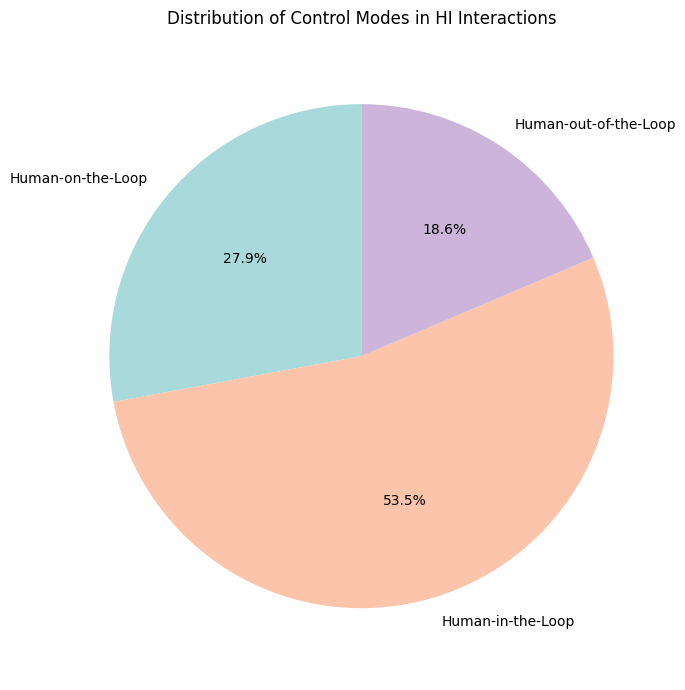

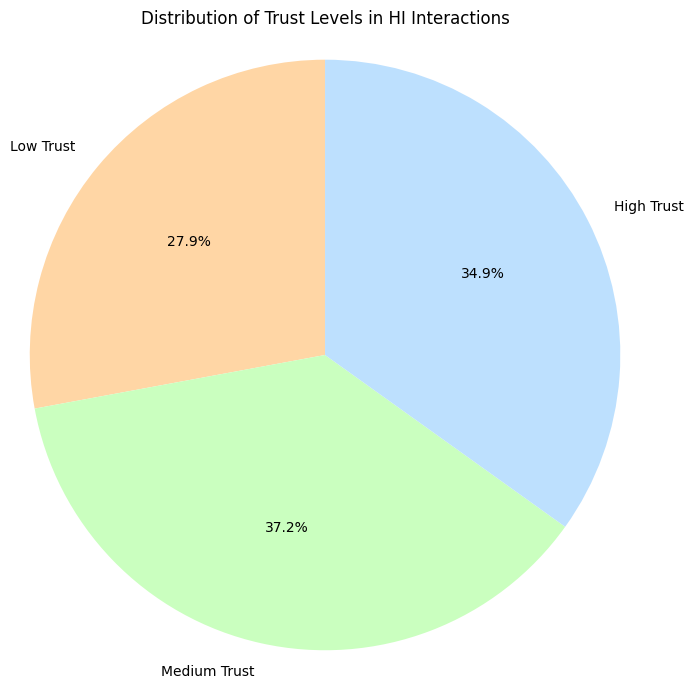

In [ ]:
control_map = {
    "hitl_mode_1": "Human-in-the-Loop",
    "hitl_mode_2": "Human-in-the-Loop",
    "hotl_mode_1": "Human-on-the-Loop",
    "hootl_mode_1": "Human-out-of-the-Loop",
}

trust_map = {
    "low_trust_case_1": "Low Trust",
    "medium_trust_case_1": "Medium Trust",
    "medium_trust_case_2": "Medium Trust",
    "high_trust_case_1": "High Trust",
    "high_trust_case_2": "High Trust",
}

control_counts = {}
trust_counts = {}

for typ, config, count in results:
    if typ == "ControlMode":
        label = control_map.get(config, config)
        control_counts[label] = control_counts.get(label, 0) + count
    elif typ == "TrustLevel":
        label = trust_map.get(config, config)
        trust_counts[label] = trust_counts.get(label, 0) + count

# color
pastel_control = ["#A8DADC", "#FBC4AB", "#CDB4DB"]
pastel_trust = ["#FFD6A5", "#CAFFBF", "#BDE0FE"]


# Plot function
def make_pie_chart(data_dict, title, filename, colors):
    labels = list(data_dict.keys())
    sizes = list(data_dict.values())

    plt.figure(figsize=(7, 7))
    plt.pie(
        sizes,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors
    )
    plt.title(title)
    plt.axis("equal")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# Create charts
make_pie_chart(
    control_counts,
    "Distribution of Control Modes in HI Interactions",
    "control_mode_pie.png",
    pastel_control
)

make_pie_chart(
    trust_counts,
    "Distribution of Trust Levels in HI Interactions",
    "trust_level_pie.png",
    pastel_trust
)

# Query 2: Decision-role distribution between human and AI actors across domains

In [ ]:
# QUERY 2: 
# grouped decision-role distribution across grouped domains
# mapping is also implemented

query = f"""
PREFIX rdf: <{RDF}>
PREFIX hi:  <{HI}>

SELECT ?broadDomain ?broadRole (COUNT(DISTINCT ?actor) AS ?n)
WHERE {{
  ?scenario rdf:type hi:Scenario ;
            hi:domain ?domain ;
            hi:hasActor ?actor .

  ?actor hi:hasDecisionRole ?role .

  BIND(REPLACE(STR(?domain), '^.*[#/]', '') AS ?domainName)
  BIND(REPLACE(STR(?role), '^.*[#/]', '') AS ?roleName)

  BIND(
    IF(?domainName IN (
        "Healthcare",
        "healthcare_domain_1"
      ),
      "Healthcare",
      IF(?domainName IN (
          "legal_domain_1"
        ),
        "Legal and Governance",
        IF(?domainName IN (
            "WarehouseAutomation",
            "AutonomousDriving",
            "logistics_domain_1"
          ),
          "Mobility and Logistics",
          "Other"
        )
      )
    ) AS ?broadDomain
  )

  BIND(
    IF(?roleName IN (
        "human_final_role_1",
        "human_final_role_2"
      ),
      "Human Final Decision",
      IF(?roleName IN (
          "ai_support_role_1",
          "ai_support_role_2"
        ),
        "AI Support",
        IF(?roleName IN (
            "shared_decision_role_1",
            "shared_decision_role_2"
          ),
          "Shared Decision",
          "Other"
        )
      )
    ) AS ?broadRole
  )

  FILTER(?broadDomain != "Other" && ?broadRole != "Other")
}}
GROUP BY ?broadDomain ?broadRole
ORDER BY ?broadDomain DESC(?n)
"""

In [ ]:

results = list(g.query(query))
rows = [(r.broadDomain, r.broadRole, r.n) for r in results]

print_results(
    "QUERY 2: Grouped decision-role distribution across grouped domains",
    rows,
    ["BroadDomain", "BroadDecisionRole", "Count"],
    max_rows=200
)


QUERY 2: Grouped decision-role distribution across grouped domains
BroadDomain | BroadDecisionRole | Count
----------------------------------------------------------------------------------------------------
Healthcare | Human Final Decision | 5
Healthcare | AI Support | 3
Legal and Governance | Human Final Decision | 10
Legal and Governance | AI Support | 8
Mobility and Logistics | AI Support | 7
Mobility and Logistics | Human Final Decision | 7



In [ ]:
results = [
    ("Healthcare", "Human Final Decision", 5),
    ("Healthcare", "AI Support", 3),
    ("Legal and Governance", "Human Final Decision", 10),
    ("Legal and Governance", "AI Support", 8),
    ("Mobility and Logistics", "Human Final Decision",7),
    ("Mobility and Logistics", "AI Support", 7),]

In [53]:

# Aggregate counts by domain and actor

counts = defaultdict(lambda: {"Human Final Decision": 0, "AI Support": 0})

for domain, actor_cat,  count in results:
    #broad_domain = domain_map.get(domain, domain)
    counts[domain][actor_cat] += int(count)

domains = sorted(counts.keys())

human_pct = []
agent_pct = []

for d in domains:
    h = counts[d]["Human Final Decision"]
    a = counts[d]["AI Support"]
    total = h + a
    if total == 0:
        human_pct.append(0)
        agent_pct.append(0)
    else:
        human_pct.append(h / total * 100)
        agent_pct.append(a / total * 100)


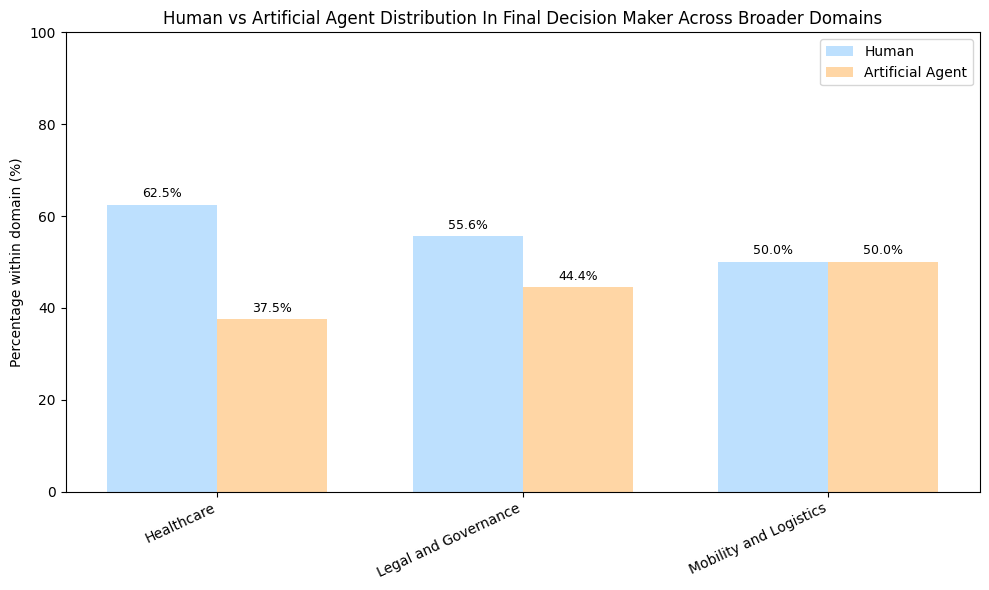

In [54]:
# PLOT
x = np.arange(len(domains))
width = 0.36

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, human_pct, width, label="Human", color="#BDE0FE")
bars2 = plt.bar(x + width/2, agent_pct, width, label="Artificial Agent", color="#FFD6A5")

plt.xticks(x, domains, rotation=25, ha="right")
plt.ylabel("Percentage within domain (%)")
plt.ylim(0, 100)
plt.title("Human vs Artificial Agent Distribution In Final Decision Maker Across Broader Domains")
plt.legend()


for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.savefig("decision_roles_dual_bar_domains_percentage.png", dpi=300, bbox_inches="tight")
plt.show()